### Carga de datos

In [109]:
#carga los datos desde el csv a pandas
import pandas as pd

def corregir_overflow(valor):
    if valor > 60000:
        return valor - 65536
    return valor

def corregir_frecuencia(valor):
    if valor > 1000:
        return valor - 65536
    if valor < 400:
        return 400
    return valor


df = pd.read_csv(
    'medicion_rows.csv',
    parse_dates=['created_at'],
    dtype={
        'frecuencia': 'int64',
        'bomba': 'bool',
        'caudal': 'int64',
        'presion': 'int64',
        'nivel': 'int64'
    }
)

# corregir el overflow en las columnas de presión y caudal
df['presion'] = df['presion'].apply(corregir_overflow)
df['caudal'] = df['caudal'].apply(corregir_overflow)
df['frecuencia'] = df['frecuencia'].apply(corregir_frecuencia)

#caculo de stokes
df['aux'] = df['frecuencia'].diff() < 0
df['stoke'] = df['aux'].cumsum() * 10 + 50

# escalamiento de los datos
df['nivel'] = df['nivel'] / 10
df['presion'] = df['presion'] / 1
df['caudal'] = df['caudal'] / 100
df['frecuencia'] = df['frecuencia'] / 10
df['bomba'] = df['bomba'].astype(int)
df['created_at'] = pd.to_datetime(df['created_at'])

# Convertir a galones
# diamentro del tanque = 120 cm -> radio = 60 cm
# Área de la sección transversal del tanque = π * r^2 = π * (60 cm)^2 ≈ 11309.73 cm²
# Volumen = Área * altura -> volumen en cm³, para convertir a galones: 1 galón ≈ 3785.41 cm³
df['volumen_real'] = df['nivel']/10 * 11309.73 / 3785.41

print(df.dtypes)
print(df.head())


created_at      datetime64[us, UTC]
frecuencia                  float64
bomba                         int64
caudal                      float64
presion                     float64
nivel                       float64
aux                            bool
stoke                         int64
volumen_real                float64
dtype: object
                        created_at  frecuencia  bomba  caudal  presion  nivel  \
0 2026-06-04 13:46:21.438931+00:00        40.0      1    0.07   3451.0  804.6   
1 2026-06-04 13:46:26.448370+00:00        40.0      1    0.07   3354.0  804.6   
2 2026-06-04 13:46:31.460547+00:00        40.0      1    0.72   3371.0  804.8   
3 2026-06-04 13:46:36.469208+00:00        40.0      1   21.23   3445.0  804.6   
4 2026-06-04 13:46:41.437713+00:00        40.0      1   69.12   3496.0  804.8   

     aux  stoke  volumen_real  
0  False     50    240.391629  
1  False     50    240.391629  
2  False     50    240.451383  
3  False     50    240.391629  
4  False     50

### Nivel vs frecuencia

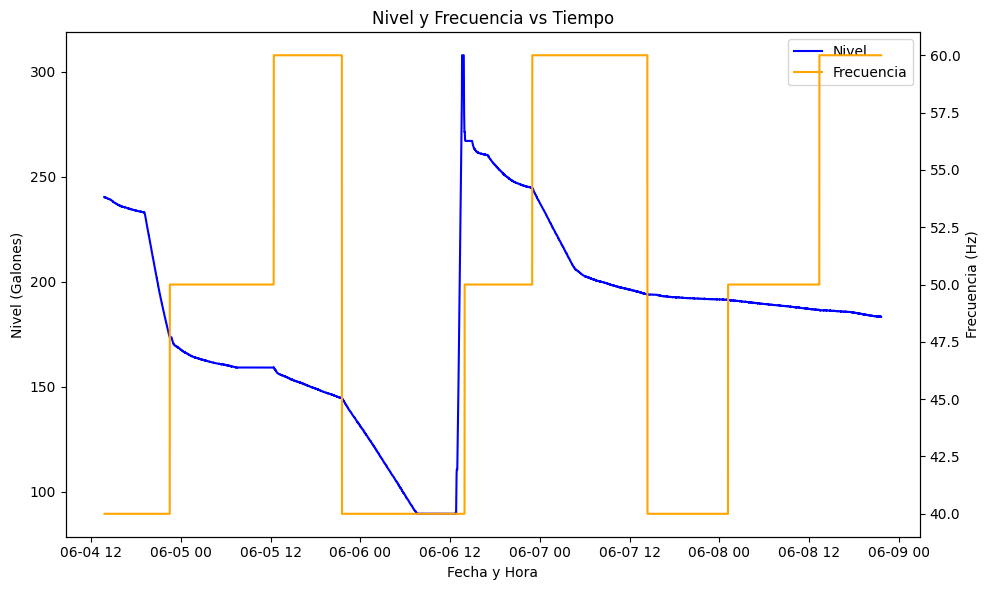

In [110]:
# variacion de nivel con respecto al tiempo
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(10, 6))

# Eje Y izquierdo
ax1.plot(df['created_at'], df['volumen_real'], label='Nivel', color='blue')
ax1.set_xlabel('Fecha y Hora')
ax1.set_ylabel('Nivel (Galones)')
ax1.tick_params(axis='y')

# Eje Y derecho
ax2 = ax1.twinx()
ax2.plot(df['created_at'], df['frecuencia'], label='Frecuencia', color='orange')
ax2.set_ylabel('Frecuencia (Hz)')
ax2.tick_params(axis='y')


# Título
plt.title('Nivel y Frecuencia vs Tiempo')

# Combinar leyendas de ambos ejes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='best')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### estimacion de caudal mediante nivel

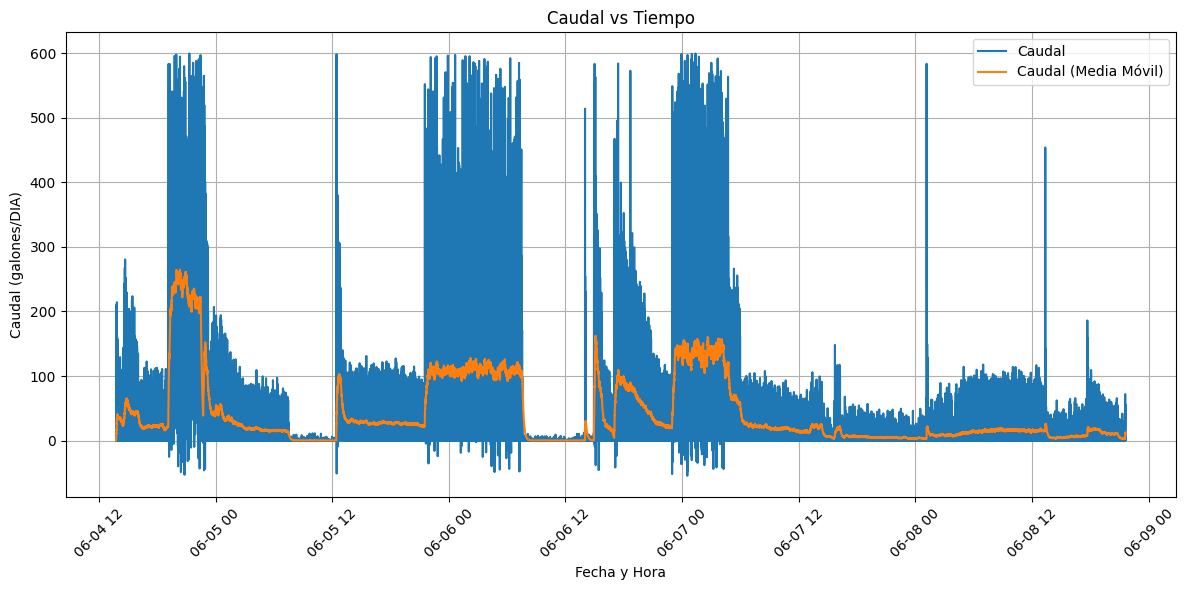

In [111]:
# GRAFICA DEL CAUDAL CON RESPECTO AL TIEMPO
df['caudal_FIT'] = ( df['caudal'].ewm(span=100, adjust=False).mean() )
plt.figure(figsize=(12,6))
plt.plot(df['created_at'], df['caudal'], label='Caudal')
plt.plot(df['created_at'], df['caudal_FIT'], label='Caudal (Media Móvil)')
plt.title('Caudal vs Tiempo')
plt.xlabel('Fecha y Hora')
plt.ylabel('Caudal (galones/DIA)')
plt.grid(True)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### caudal y presion

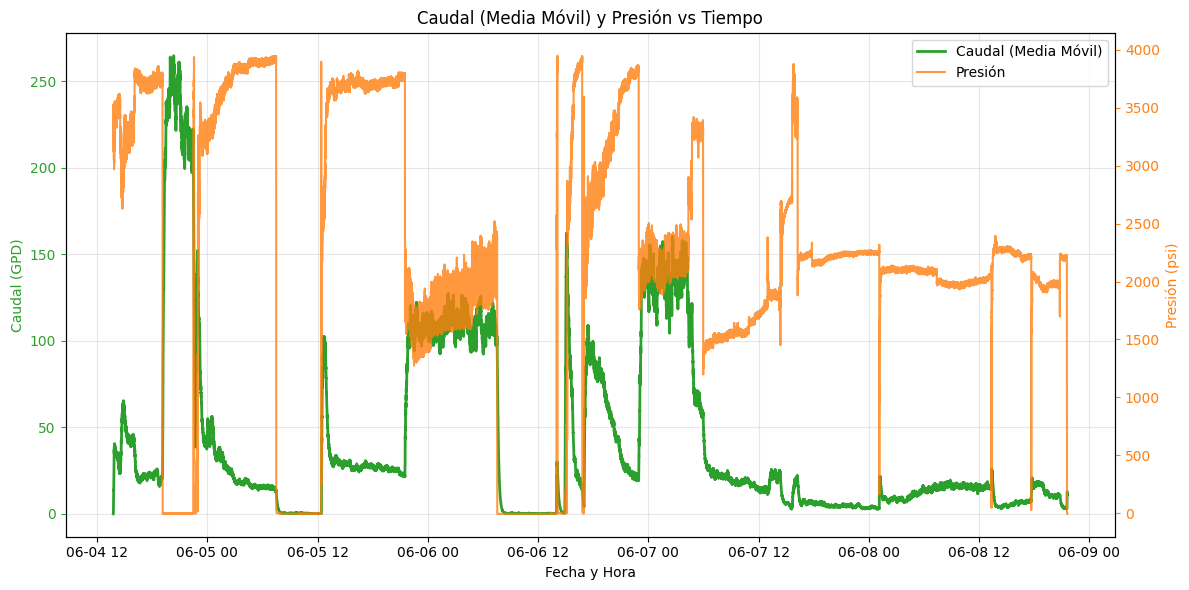

In [112]:
plt.figure(figsize=(12,6))

ax1 = plt.gca()

# Caudal
ax1.plot(
    df['created_at'],
    df['caudal_FIT'],
    label='Caudal (Media Móvil)',
    color='tab:green',
    linewidth=2
)

ax1.set_xlabel('Fecha y Hora')
ax1.set_ylabel('Caudal (GPD)', color='tab:green')
ax1.tick_params(axis='y', colors='tab:green')

# Presión
ax2 = ax1.twinx()

ax2.plot(
    df['created_at'],
    df['presion'],
    label='Presión',
    color='tab:orange',
    linewidth=1.5,
    alpha=0.8
)

ax2.set_ylabel('Presión (psi)', color='tab:orange')
ax2.tick_params(axis='y', colors='tab:orange')

plt.title('Caudal (Media Móvil) y Presión vs Tiempo')

# Cuadrícula más suave
ax1.grid(True, alpha=0.3)

# Leyenda conjunta
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc='upper right'
)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Error caudal medido y estimado por nivel

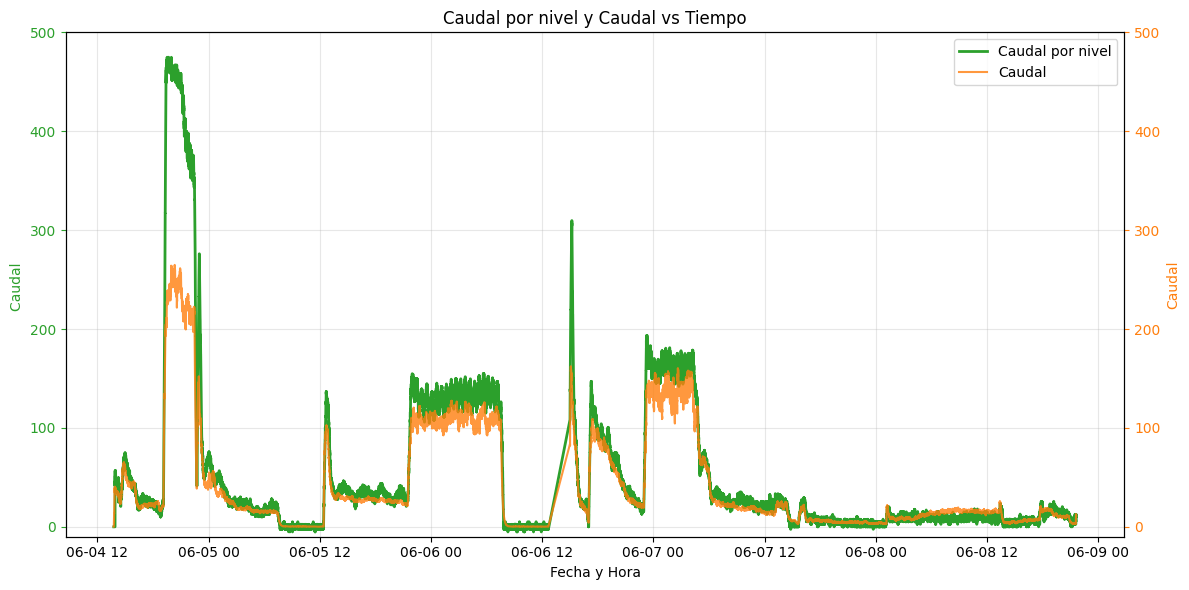

C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


(-10.0, 10.0)

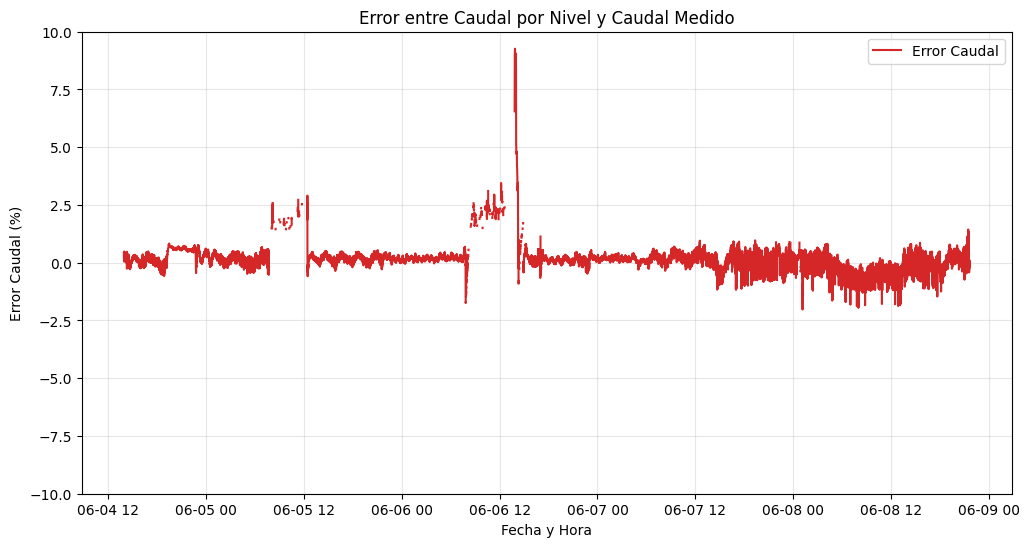

In [113]:
import numpy as np
# caudal a partir del nivel
df['caudal_nivel'] = -( df['volumen_real'].diff(periods=100) )/ ( df['created_at'].diff(periods=100).dt.total_seconds() / 86400 )
df['caudal_nivel'] = df['caudal_nivel'].fillna(0)
#gracfica solo 2 dias de caudal a partir del nivel
#df_sin_refill = df
df_sin_refill = df[(df['created_at'] < "2026-06-06 12:40:00") | (df['created_at'] > "2026-06-06 15:00:00")]
#df_sin_refill = df[(df['created_at'] < "2026-06-06 12:40:00")]
plt.figure(figsize=(12,6))
ax1 = plt.gca()
ax1.plot(df_sin_refill['created_at'], df_sin_refill['caudal_nivel'], label='Caudal por nivel', color='tab:green', linewidth=2)
ax1.set_xlabel('Fecha y Hora')
ax1.set_ylabel('Caudal ', color='tab:green')
ax1.tick_params(axis='y', colors='tab:green')
ax1.set_ylim(-10, 500)

ax2 = ax1.twinx()
ax2.plot(df_sin_refill['created_at'],df_sin_refill['caudal_FIT'], label='Caudal', color='tab:orange', linewidth=1.5, alpha=0.8)
ax2.set_ylabel('Caudal', color='tab:orange')
ax2.tick_params(axis='y', colors='tab:orange')
ax2.set_ylim(-10, 500)
plt.title('Caudal por nivel y Caudal vs Tiempo')
ax1.grid(True, alpha=0.3)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# grafica del error entre el caudal por nivel y el caudal medido

df['error_caudal'] = np.log(df['caudal_nivel']) - np.log(df['caudal_FIT'])
plt.figure(figsize=(12,6))
plt.plot(df['created_at'], df['error_caudal'], label='Error Caudal', color='tab:red', linewidth=1.5)
plt.xlabel('Fecha y Hora')
plt.ylabel('Error Caudal (%)')
plt.title('Error entre Caudal por Nivel y Caudal Medido')
plt.grid(True, alpha=0.3)
plt.legend()
plt.ylim(-10, 10)

In [114]:
print(df['caudal_nivel'])


0         0.000000
1         0.000000
2         0.000000
3         0.000000
4         0.000000
           ...    
36922    12.527026
36923    12.527095
36924    10.021449
36925    12.525615
36926    10.022335
Name: caudal_nivel, Length: 36927, dtype: float64


### Potencia hidrahulica

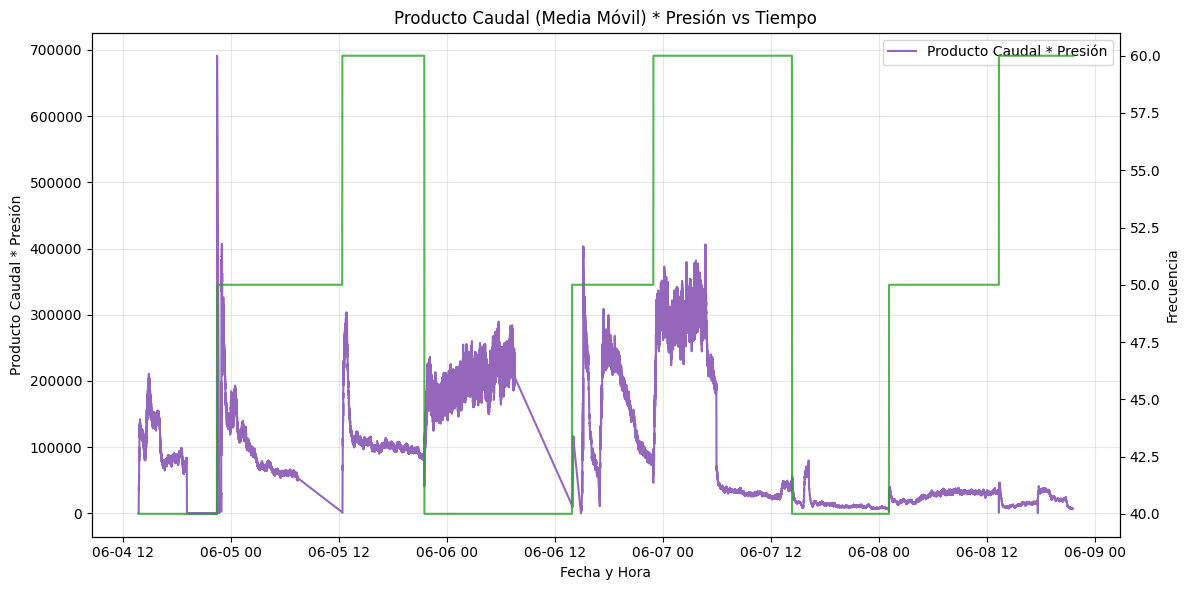

In [115]:
df['producto'] = df['caudal_FIT']* df['presion'] 

plt.figure(figsize=(12,6))
ax1 = plt.gca()
ax1.plot(df['created_at'][df['bomba'] == 1], df['producto'][df['bomba'] == 1], label='Producto Caudal * Presión', color='tab:purple', linewidth=1.5)
ax1.set_xlabel('Fecha y Hora')
ax1.set_ylabel('Producto Caudal * Presión')
ax1.set_title('Producto Caudal (Media Móvil) * Presión vs Tiempo')
ax1.grid(True, alpha=0.3)
ax1.legend()

ax2 = ax1.twinx()
ax2.plot(df['created_at'], df['frecuencia'], label='Nivel', color='tab:green', linewidth=1.5, alpha=0.8)
ax2.set_ylabel('Frecuencia')
plt.tight_layout()

### caudal mientras esta encendido

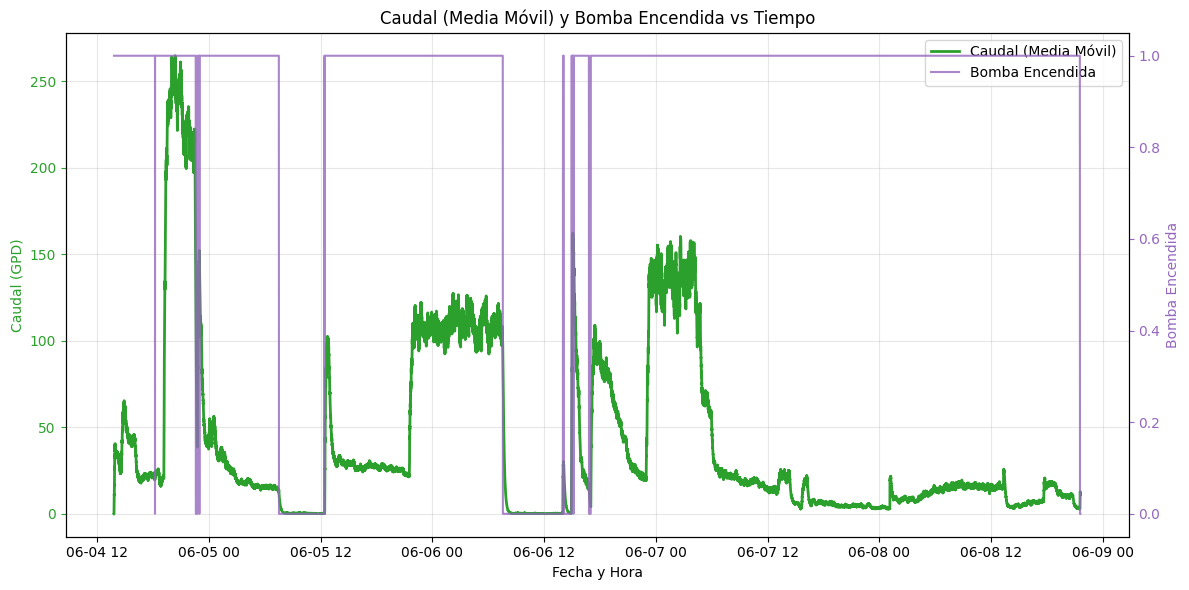

In [116]:
plt.figure(figsize=(12,6))
ax1 = plt.gca()
ax1.plot(
    df['created_at'],
    df['caudal_FIT'],
    label='Caudal (Media Móvil)',
    color='tab:green',
    linewidth=2
)

ax1.set_xlabel('Fecha y Hora')
ax1.set_ylabel('Caudal (GPD)', color='tab:green')
ax1.tick_params(axis='y', colors='tab:green')
ax2 = ax1.twinx()
ax2.plot(
    df['created_at'],
    df['bomba'],
    label='Bomba Encendida',
    color='tab:purple',
    linewidth=1.5,
    alpha=0.8
)

ax2.set_ylabel('Bomba Encendida', color='tab:purple')
ax2.tick_params(axis='y', colors='tab:purple')
plt.title('Caudal (Media Móvil) y Bomba Encendida vs Tiempo')
ax1.grid(True, alpha=0.3)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### Presion mientras esta encendido

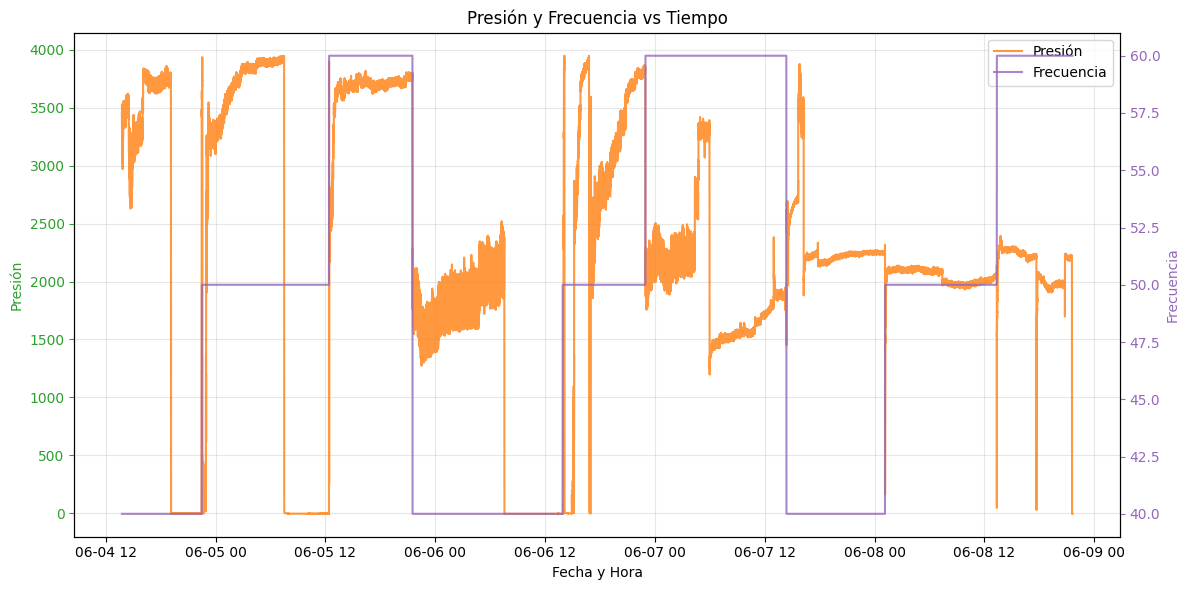

In [117]:
plt.figure(figsize=(12,6))
ax1 = plt.gca()
ax1.plot(
    df['created_at'],
    df['presion'],
    label='Presión',
    color='tab:orange',
    linewidth=1.5,
    alpha=0.8
)


ax1.set_xlabel('Fecha y Hora')
ax1.set_ylabel('Presión', color='tab:green')
ax1.tick_params(axis='y', colors='tab:green')
ax2 = ax1.twinx()
ax2.plot(
    df['created_at'],
    df['frecuencia'],
    label='Frecuencia',
    color='tab:purple',
    linewidth=1.5,
    alpha=0.8
)

ax2.set_ylabel('Frecuencia', color='tab:purple')
ax2.tick_params(axis='y', colors='tab:purple')
plt.title('Presión y Frecuencia vs Tiempo')
ax1.grid(True, alpha=0.3)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### limpieza y exportar datos

In [118]:
print(df.head())
try:
    clomuns_a_exportar = ['created_at', 'frecuencia','bomba', 'caudal_FIT', 'presion', 'caudal_nivel', 'stoke']
    columnas_existentes = df.columns.tolist()
    columnas_a_eliminar = [col for col in clomuns_a_exportar if col not in columnas_existentes]
    if columnas_a_eliminar:
        print(f"Las siguientes columnas no existen en el DataFrame y no se podrán exportar: {', '.join(columnas_a_eliminar)}")
    else:
        df_exportar = df[clomuns_a_exportar]
        df_exportar.to_csv('datos_prueba_5_dias.csv', index=False)
        print("Datos exportados correctamente a 'datos_prueba_5_dias.csv'")
except KeyError:
    print("Las columnas 'error_caudal' o 'producto' no existen en el DataFrame.")

                        created_at  frecuencia  bomba  caudal  presion  nivel  \
0 2026-06-04 13:46:21.438931+00:00        40.0      1    0.07   3451.0  804.6   
1 2026-06-04 13:46:26.448370+00:00        40.0      1    0.07   3354.0  804.6   
2 2026-06-04 13:46:31.460547+00:00        40.0      1    0.72   3371.0  804.8   
3 2026-06-04 13:46:36.469208+00:00        40.0      1   21.23   3445.0  804.6   
4 2026-06-04 13:46:41.437713+00:00        40.0      1   69.12   3496.0  804.8   

     aux  stoke  volumen_real  caudal_FIT  caudal_nivel  error_caudal  \
0  False     50    240.391629    0.070000           0.0          -inf   
1  False     50    240.391629    0.070000           0.0          -inf   
2  False     50    240.451383    0.082871           0.0          -inf   
3  False     50    240.391629    0.501626           0.0          -inf   
4  False     50    240.451383    1.860406           0.0          -inf   

      producto  
0   241.570000  
1   234.780000  
2   279.359109  
3  172

### stroke y frecuencia

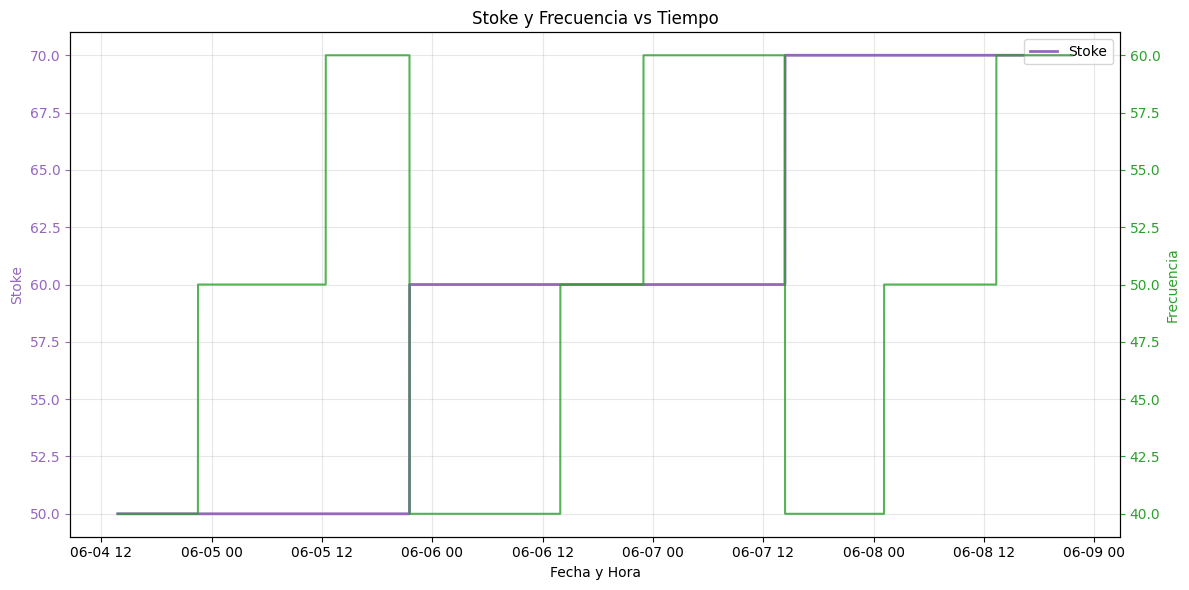

In [119]:
plt.figure(figsize=(12,6))
ax1 = plt.gca()
ax1.plot(df['created_at'], df['stoke'], label='Stoke', color='tab:purple', linewidth=2)
ax1.set_xlabel('Fecha y Hora')
ax1.set_ylabel('Stoke', color='tab:purple')
ax1.tick_params(axis='y', colors='tab:purple')
ax1.grid(True, alpha=0.3)
ax1.legend(loc='upper right')

ax2 = ax1.twinx()
ax2.plot(df['created_at'], df['frecuencia'], label='Frecuencia', color='tab:green', linewidth=1.5, alpha=0.8)
ax2.set_ylabel('Frecuencia', color='tab:green')
ax2.tick_params(axis='y', colors='tab:green')
plt.title('Stoke y Frecuencia vs Tiempo')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Graficas stoke y caudal

In [120]:
# los rangos de tiempo para las combinaciones de 40 50 60 hz y 50 60 70 stroke
frecuencias = [40, 50, 60]
stokes = [50, 60, 70]
rangos_tiempo = {}
for f in frecuencias:
    for s in stokes:
        df_filtrado = df[(df['frecuencia'] == f) & (df['stoke'] == s) & (df['bomba'] == 1)]
        if not df_filtrado.empty:
            tiempo_inicio = df_filtrado['created_at'].min()
            tiempo_fin = df_filtrado['created_at'].max()
            presion_promedio = df_filtrado['presion'].mean()
            caudal_promedio = df_filtrado['caudal_FIT'].mean()
            rangos_tiempo[(f, s)] = (tiempo_inicio, tiempo_fin, presion_promedio, caudal_promedio)
            
print("Rangos de tiempo para combinaciones de Frecuencia y Stoke:")
for (f, s), (inicio, fin, presion, caudal) in rangos_tiempo.items():
    print(f"Frecuencia: {f} Hz, Stoke: {s} ->  Presión Promedio: {presion:.2f} psi, Caudal Promedio: {caudal:.2f} GPD")


Rangos de tiempo para combinaciones de Frecuencia y Stoke:
Frecuencia: 40 Hz, Stoke: 50 ->  Presión Promedio: 2220.74 psi, Caudal Promedio: 102.44 GPD
Frecuencia: 40 Hz, Stoke: 60 ->  Presión Promedio: 1874.85 psi, Caudal Promedio: 107.02 GPD
Frecuencia: 40 Hz, Stoke: 70 ->  Presión Promedio: 2341.81 psi, Caudal Promedio: 6.04 GPD
Frecuencia: 50 Hz, Stoke: 50 ->  Presión Promedio: 3596.80 psi, Caudal Promedio: 31.72 GPD
Frecuencia: 50 Hz, Stoke: 60 ->  Presión Promedio: 3173.20 psi, Caudal Promedio: 55.54 GPD
Frecuencia: 50 Hz, Stoke: 70 ->  Presión Promedio: 2042.87 psi, Caudal Promedio: 13.44 GPD
Frecuencia: 60 Hz, Stoke: 50 ->  Presión Promedio: 3653.10 psi, Caudal Promedio: 31.32 GPD
Frecuencia: 60 Hz, Stoke: 60 ->  Presión Promedio: 1997.58 psi, Caudal Promedio: 66.03 GPD
Frecuencia: 60 Hz, Stoke: 70 ->  Presión Promedio: 2134.07 psi, Caudal Promedio: 9.07 GPD


In [121]:
from collections import defaultdict

presiones = defaultdict(dict)
caudales = defaultdict(dict)

for (f, s), (inicio, fin, presion, caudal) in rangos_tiempo.items():
    presiones[f][s] = presion
    caudales[f][s] = caudal

df_resumen = pd.DataFrame([
    {
        "frecuencia": f,
        "stoke": s,
        "presion": presion,
        "caudal": caudal
    }
    for (f, s), (_, _, presion, caudal) in rangos_tiempo.items()
])

print(df_resumen)

tabla_presion = df_resumen.pivot(
    index="stoke",
    columns="frecuencia",
    values="presion"
)

tabla_caudal = df_resumen.pivot(
    index="stoke",
    columns="frecuencia",
    values="caudal"
)


   frecuencia  stoke      presion      caudal
0          40     50  2220.735967  102.435191
1          40     60  1874.853556  107.020155
2          40     70  2341.811824    6.040826
3          50     50  3596.803708   31.715405
4          50     60  3173.202398   55.541294
5          50     70  2042.869766   13.441017
6          60     50  3653.099107   31.322256
7          60     60  1997.577950   66.029457
8          60     70  2134.073129    9.071905


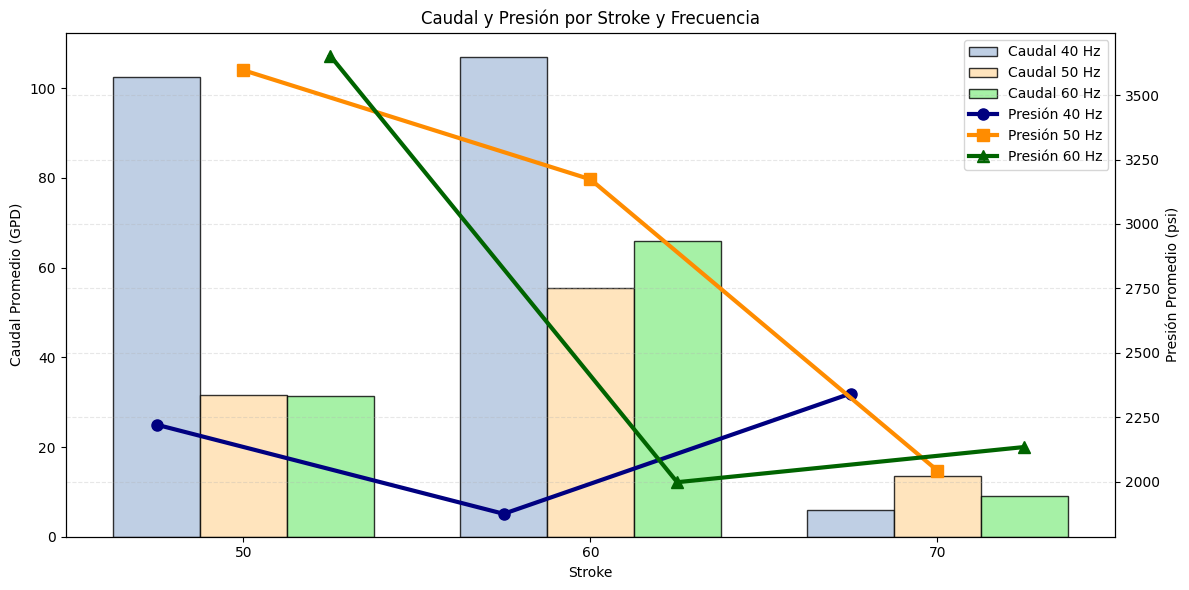

In [122]:
import numpy as np
import matplotlib.pyplot as plt

strokes = [50, 60, 70]
frecuencias = sorted(presiones.keys())

x = np.arange(len(strokes))
ancho = 0.25

fig, ax1 = plt.subplots(figsize=(12,6))

# Colores para caudal
colores_barras = ['lightsteelblue', 'navajowhite', 'lightgreen']

# Colores para presión
colores_lineas = ['navy', 'darkorange', 'darkgreen']

for i, f in enumerate(frecuencias):
    caudal_vals = [caudales[f][s] for s in strokes]

    ax1.bar(
        x + (i-1)*ancho,
        caudal_vals,
        width=ancho,
        color=colores_barras[i],
        edgecolor='black',
        alpha=0.8,
        label=f'Caudal {f} Hz'
    )

ax1.set_ylabel("Caudal Promedio (GPD)")
ax1.set_xlabel("Stroke")
ax1.set_xticks(x)
ax1.set_xticklabels(strokes)

ax2 = ax1.twinx()

marcadores = ['o', 's', '^']

for i, f in enumerate(frecuencias):
    presion_vals = [presiones[f][s] for s in strokes]

    ax2.plot(
        x + (i-1)*ancho,
        presion_vals,
        color=colores_lineas[i],
        marker=marcadores[i],
        markersize=8,
        linewidth=3,
        label=f'Presión {f} Hz'
    )

ax2.set_ylabel("Presión Promedio (psi)")

h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()

ax1.legend(
    h1 + h2,
    l1 + l2,
    bbox_to_anchor=(1, 1)
)

plt.title("Caudal y Presión por Stroke y Frecuencia")
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

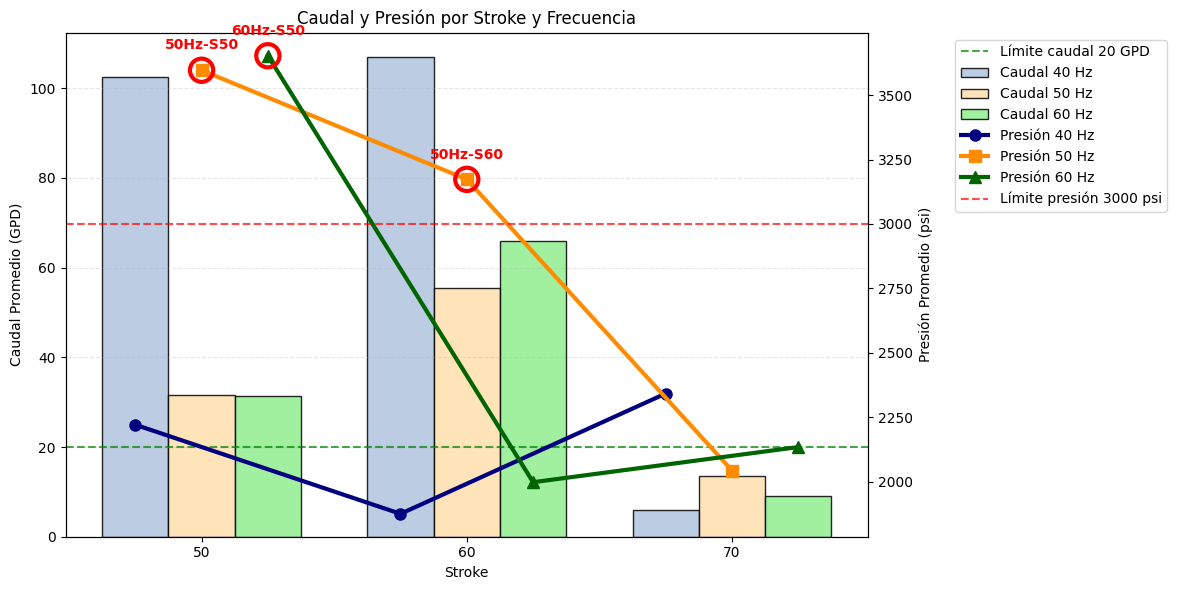

In [123]:
# Diccionarios desde rangos_tiempo
presiones = {}
caudales = {}
p_min = 3000
c_min = 20


for (f, s), (inicio, fin, presion, caudal) in rangos_tiempo.items():
    if f not in presiones:
        presiones[f] = {}
    if f not in caudales:
        caudales[f] = {}

    presiones[f][s] = presion
    caudales[f][s] = caudal

# Ordenar frecuencias y strokes
frecuencias = sorted(presiones.keys())
strokes = sorted({s for datos in presiones.values() for s in datos.keys()})

x = np.arange(len(strokes))
ancho = 0.25

fig, ax1 = plt.subplots(figsize=(12, 6))

# Colores
colores_barras = ['lightsteelblue', 'navajowhite', 'lightgreen']
colores_lineas = ['navy', 'darkorange', 'darkgreen']
marcadores = ['o', 's', '^']

# Barras: Caudal
for i, f in enumerate(frecuencias):
    caudal_vals = [caudales[f].get(s, np.nan) for s in strokes]

    ax1.bar(
        x + (i - 1) * ancho,
        caudal_vals,
        width=ancho,
        color=colores_barras[i],
        edgecolor='black',
        alpha=0.85,
        label=f'Caudal {f} Hz'
    )

ax1.set_xlabel("Stroke")
ax1.set_ylabel("Caudal Promedio (GPD)")
ax1.set_xticks(x)
ax1.set_xticklabels(strokes)
ax1.axhline(20, color='green', linestyle='--', alpha=0.7, label='Límite caudal 20 GPD')

# Eje derecho: Presión
ax2 = ax1.twinx()

for i, f in enumerate(frecuencias):
    presion_vals = [presiones[f].get(s, np.nan) for s in strokes]

    ax2.plot(
        x + (i - 1) * ancho,
        presion_vals,
        color=colores_lineas[i],
        marker=marcadores[i],
        markersize=8,
        linewidth=3,
        label=f'Presión {f} Hz'
    )

ax2.set_ylabel("Presión Promedio (psi)")
ax2.axhline(3000, color='red', linestyle='--', alpha=0.7, label='Límite presión 3000 psi')

# Resaltar combinaciones que cumplen:
# presión > 3000 psi y caudal > 20 GPD
for i, f in enumerate(frecuencias):
    for j, s in enumerate(strokes):

        p = presiones[f].get(s, np.nan)
        c = caudales[f].get(s, np.nan)

        if p > p_min and c > c_min:
            x_pos = x[j] + (i - 1) * ancho

            ax2.scatter(
                x_pos,
                p,
                s=280,
                facecolors='none',
                edgecolors='red',
                linewidths=3,
                zorder=10
            )

            ax2.annotate(
                f'{f}Hz-S{s}',
                (x_pos, p),
                xytext=(0, 15),
                textcoords='offset points',
                ha='center',
                color='red',
                fontweight='bold'
            )

# Leyenda combinada
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()

ax1.legend(
    h1 + h2,
    l1 + l2,
    loc='upper left',
    bbox_to_anchor=(1.1, 1)
)

plt.title("Caudal y Presión por Stroke y Frecuencia")
ax1.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

### Graficas de cada combinacion

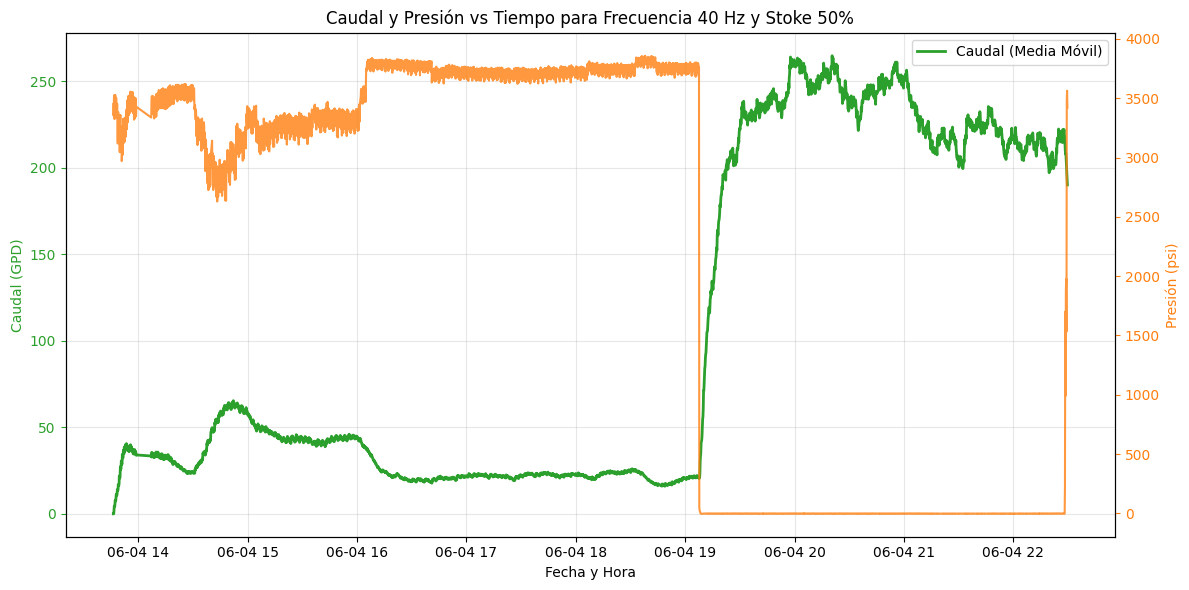

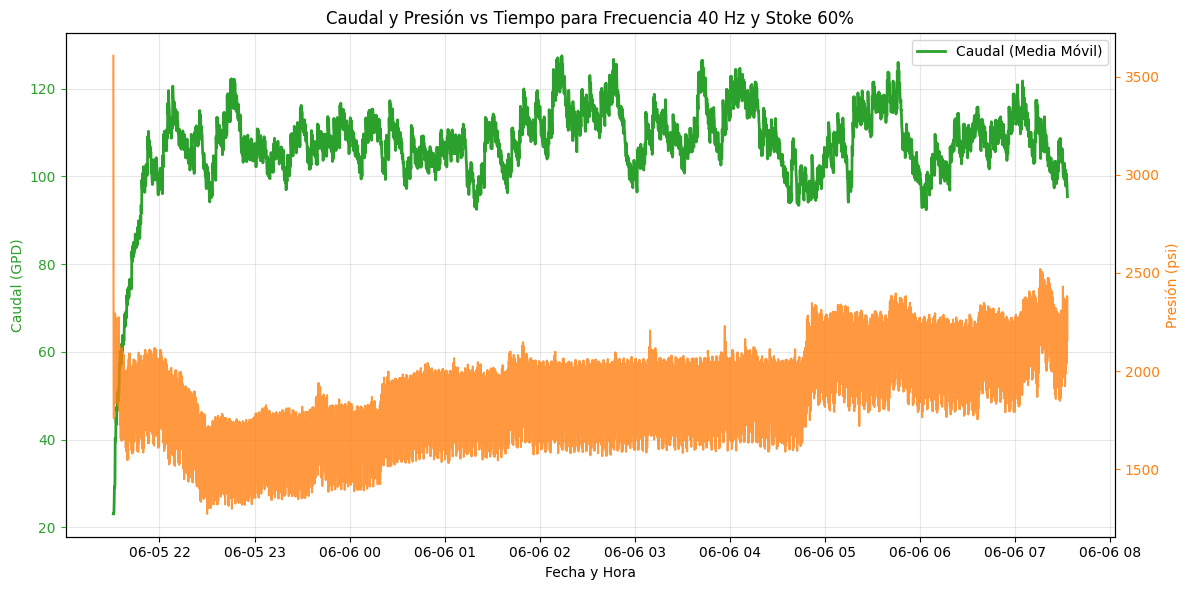

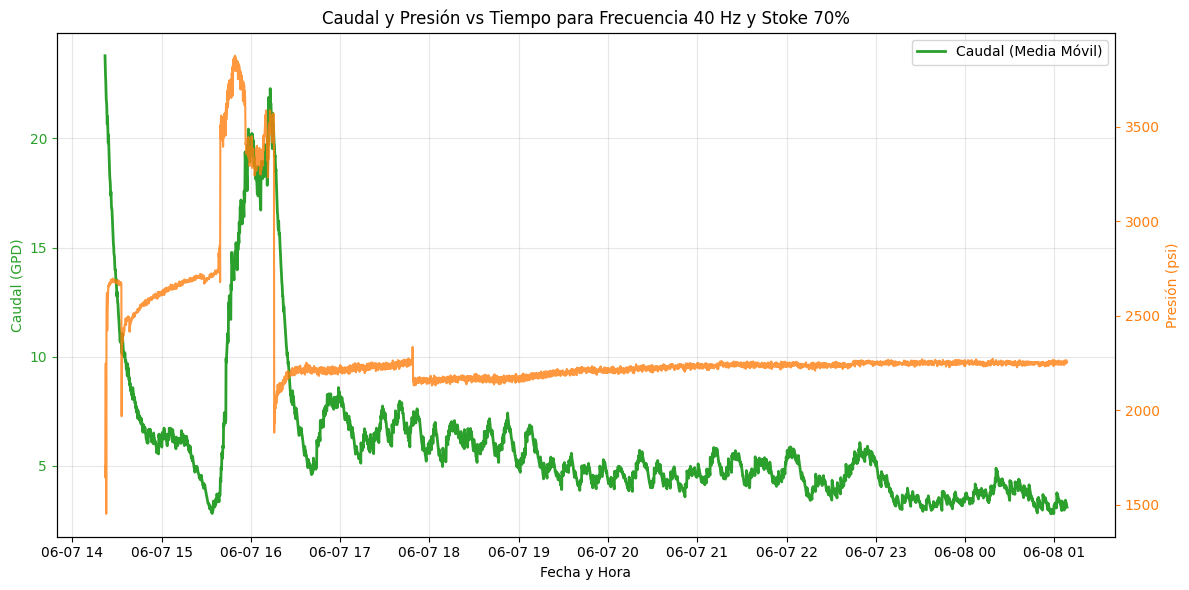

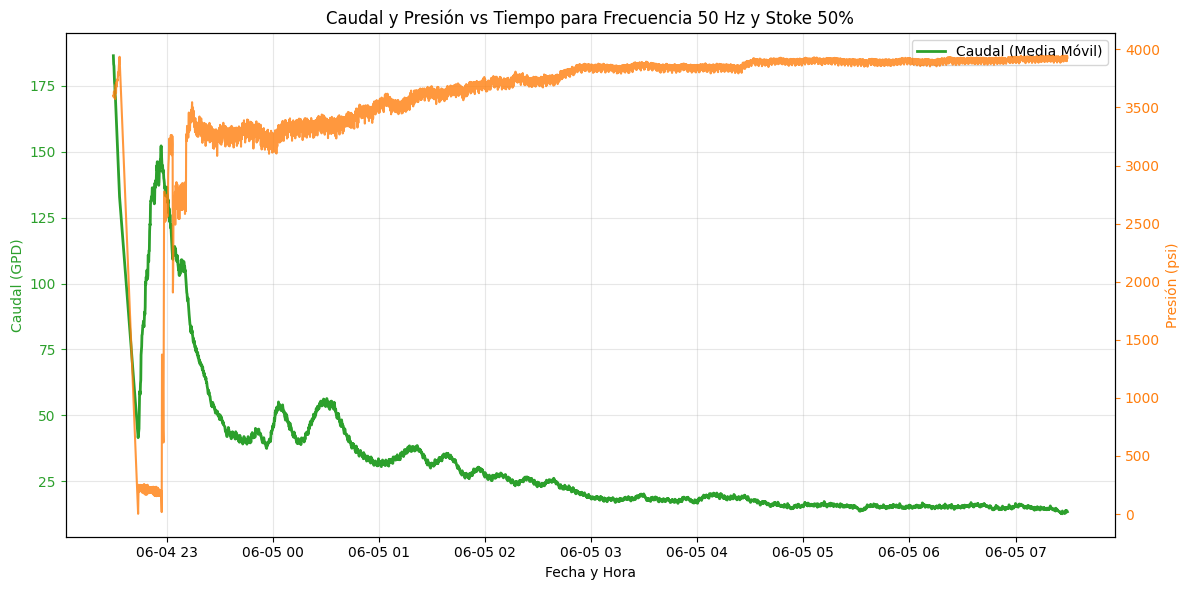

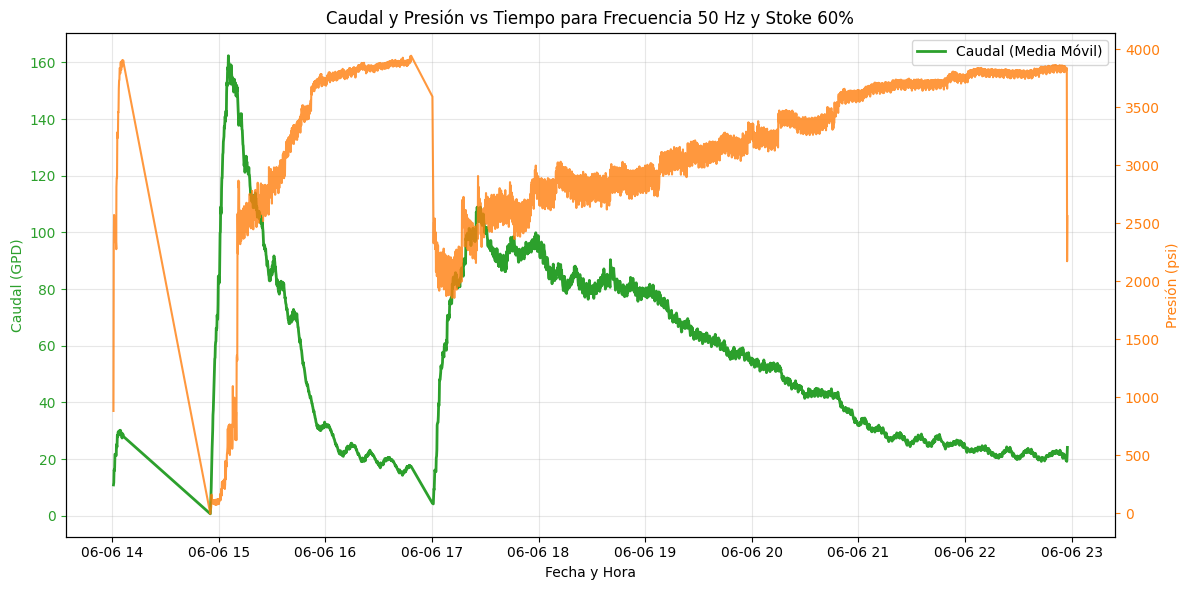

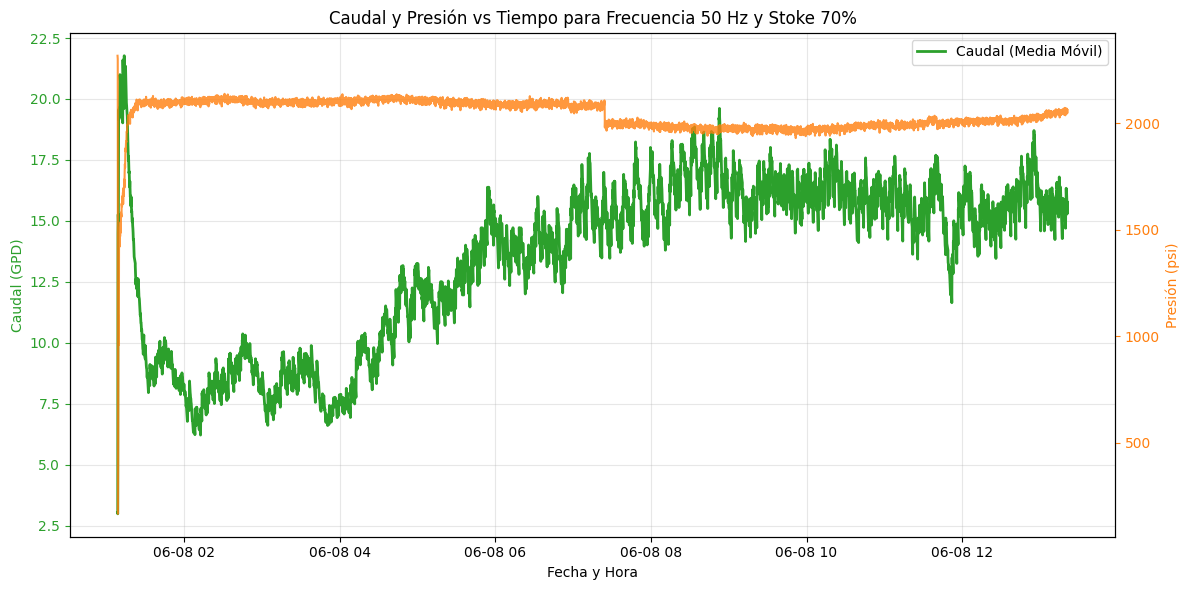

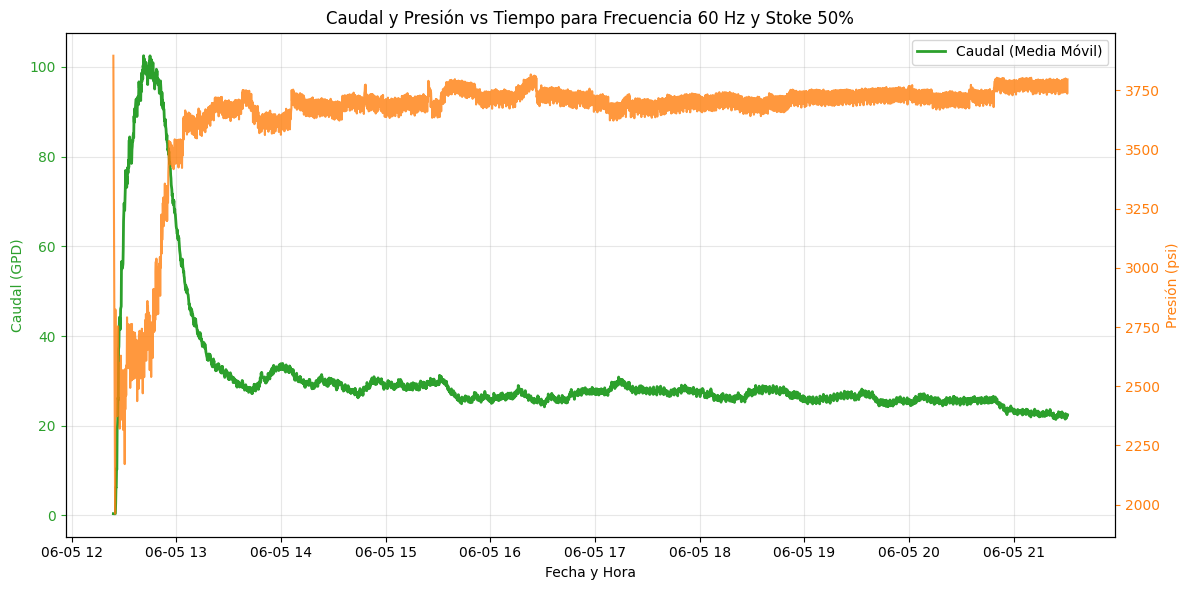

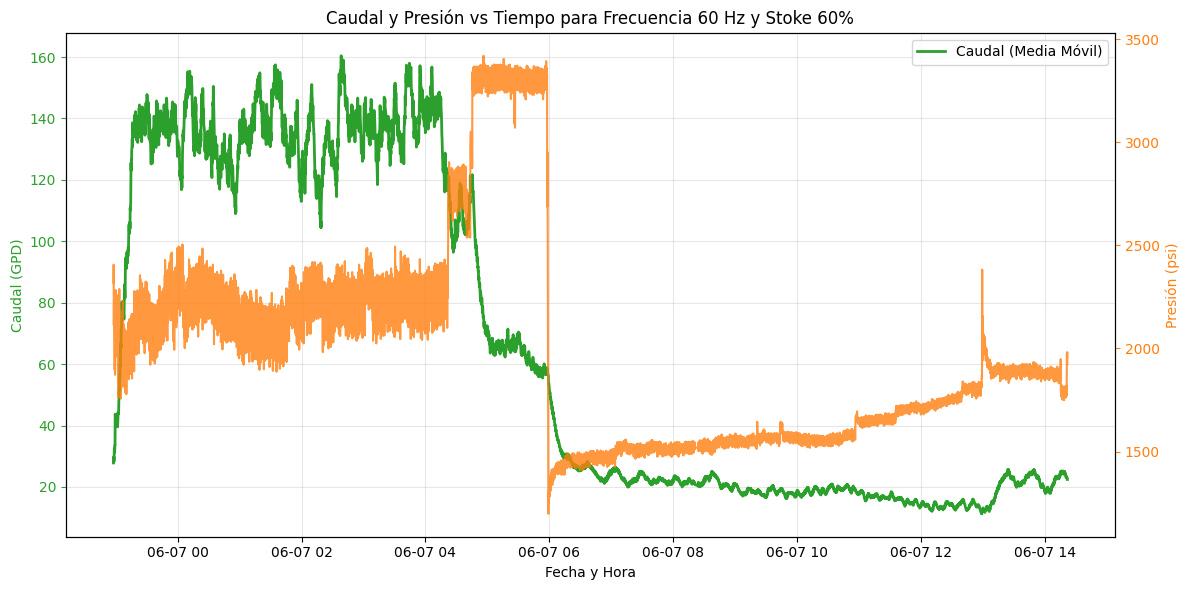

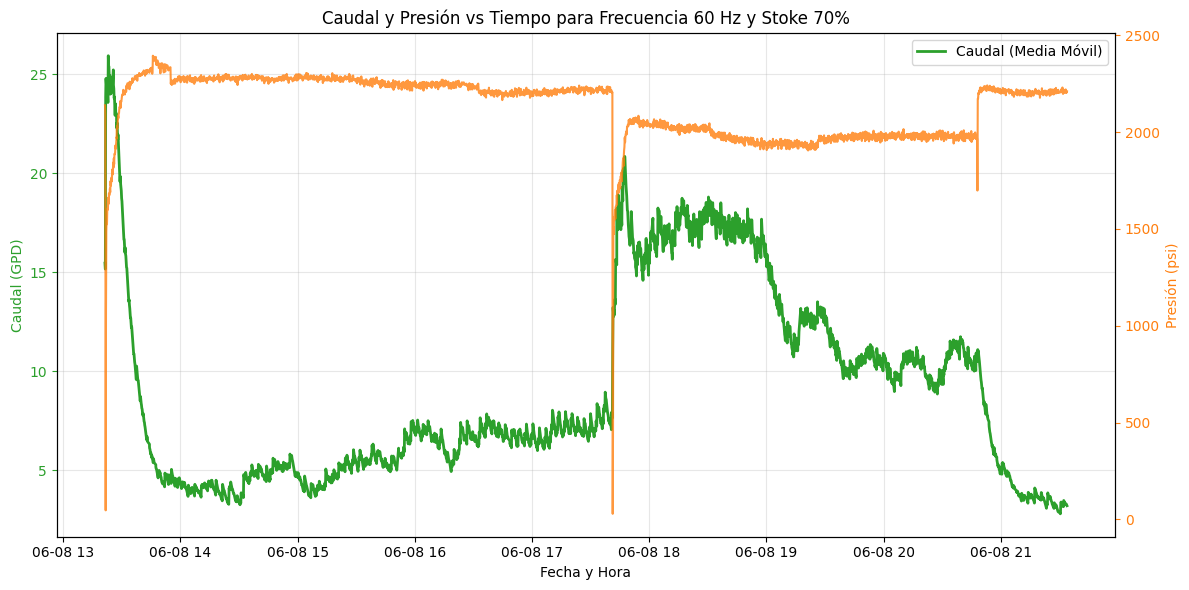

In [124]:
# grafica de stoke y caudal para cada combinacion de frecuencia y stoke
for (f, s), (inicio, fin, presion, caudal) in rangos_tiempo.items():
    df_filtrado = df[(df['frecuencia'] == f) & (df['stoke'] == s) & (df['bomba'] == 1)]
    plt.figure(figsize=(12,6))
    ax1 = plt.gca()
    ax1.plot(df_filtrado['created_at'], df_filtrado['caudal_FIT'], label='Caudal (Media Móvil)', color='tab:green', linewidth=2)
    ax1.set_xlabel('Fecha y Hora')
    ax1.set_ylabel('Caudal (GPD)', color='tab:green')
    ax1.tick_params(axis='y', colors='tab:green')
    ax1.grid(True, alpha=0.3)
    ax1.legend(loc='upper right')
    
    ax2 = ax1.twinx()
    ax2.plot(df_filtrado['created_at'], df_filtrado['presion'], label='Presión', color='tab:orange', linewidth=1.5, alpha=0.8)
    ax2.set_ylabel('Presión (psi)', color='tab:orange')
    ax2.tick_params(axis='y', colors='tab:orange')
    
    plt.title(f'Caudal y Presión vs Tiempo para Frecuencia {f} Hz y Stoke {s}%')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

